# Score Driven Diagnostics
PED may be biased for SSMs. Using an oracle to check:

In [ ]:
# reproduce the single dataset from inference.ipynb so oracle objects match
import robust_ssm as ss
import numpy as np
SEED = 123

p_inf   = ss.ModelParams(nu=8.0, phi=0.8, sigma=1.0, w=1.0, T=300, N=1000, seed=SEED)
rng_inf = np.random.default_rng(SEED)
mu_inf, y_inf = ss.simulate(p_inf, rng_inf)

Oracle MLE sigma: 1.033


/var/folders/9z/nmz60b152q10l03t3_0by17c0000gp/T/ipykernel_64560/3772822714.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


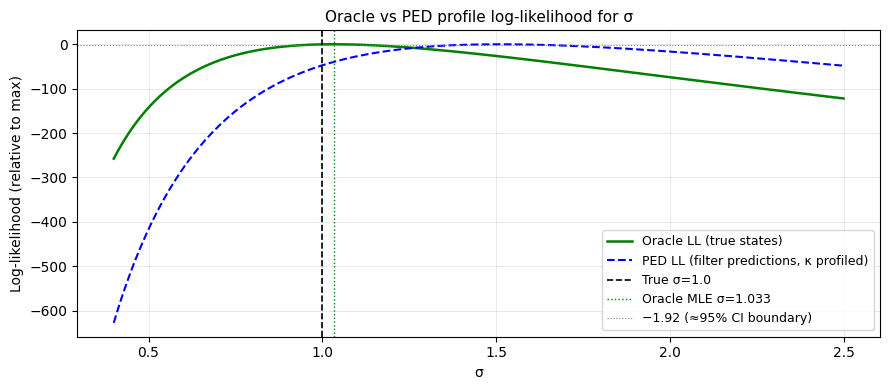

In [18]:
sigma_hat, fig = ss.estimate_sigma_oracle(y_inf, mu_inf, p_inf)
fig.show()
print(f"Oracle MLE sigma: {sigma_hat:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import replace

import robust_ssm as ss

SEED       = 42
N_ITER     = 4000
N_PARTICLES = 1000 
BURN       = N_ITER // 2

TRUE = dict(phi=0.8, sigma=1.0, w=1.0)

NU_VALUES = [3, 4, 6, 8, 12, 20, 50, 100, 300]

# nu is overridden in each experiment
def make_params(nu, seed=SEED):
    return ss.ModelParams(
        phi=TRUE['phi'], sigma=TRUE['sigma'], nu=nu, w=TRUE['w'],
        T=300, N=N_PARTICLES, seed=seed,
    )

## MC-averaged bias curve, multiple datasets per ν


**Warning:** slow

In [ ]:
N_MC      = 7     # datasets per nu
N_ITER_MC = 800   # PMCMC iterations per run (burn-in = first half)
BURN_MC   = N_ITER_MC // 2
N_PART_MC = 500   # particles per run

mc_bias = {}   # nu -> list of (posterior_mean - true_phi)

for nu in NU_VALUES:
    mc_bias[nu] = []
    print(f'ν={nu}:', end=' ', flush=True)
    for rep in range(N_MC):
        p_i   = make_params(nu, seed=SEED + rep * 1000)
        rng_i = np.random.default_rng(SEED + rep * 1000)
        _, y_i = ss.simulate(p_i, rng_i)

        res_i = ss.pmcmc_inference(
            y_i, p_i,
            n_iter=N_ITER_MC,
            free=('phi',),
            proposal_sd={'phi': 0.50},
            n_particles=N_PART_MC,
            seed=SEED + rep,
            reparameterise=True,
        )
        phi_m = res_i['samples']['phi'][BURN_MC:].mean()
        mc_bias[nu].append(phi_m - TRUE['phi'])
        print(f'{phi_m:.3f}', end=' ', flush=True)
    print(f'  mean bias={np.mean(mc_bias[nu]):+.4f}')

ν=3: 

  [PMCMC] phi    acceptance rate: 0.297  (ok)
0.663   [PMCMC] phi    acceptance rate: 0.285  (ok)
0.748   [PMCMC] phi    acceptance rate: 0.269  (ok)
0.767   [PMCMC] phi    acceptance rate: 0.315  (ok)
0.817   [PMCMC] phi    acceptance rate: 0.311  (ok)
0.826   [PMCMC] phi    acceptance rate: 0.320  (ok)
0.788   [PMCMC] phi    acceptance rate: 0.287  (ok)
0.883   mean bias=-0.0154
ν=4:   [PMCMC] phi    acceptance rate: 0.274  (ok)
0.658   [PMCMC] phi    acceptance rate: 0.296  (ok)
0.755   [PMCMC] phi    acceptance rate: 0.376  (ok)
0.853   [PMCMC] phi    acceptance rate: 0.300  (ok)
0.805   [PMCMC] phi    acceptance rate: 0.326  (ok)
0.810   [PMCMC] phi    acceptance rate: 0.326  (ok)
0.773   [PMCMC] phi    acceptance rate: 0.328  (ok)
0.884   mean bias=-0.0086
ν=6:   [PMCMC] phi    acceptance rate: 0.330  (ok)
0.694   [PMCMC] phi    acceptance rate: 0.343  (ok)
0.758   [PMCMC] phi    acceptance rate: 0.340  (ok)
0.812   [PMCMC] phi    acceptance rate: 0.310  (ok)
0.795   [PMCMC] phi 

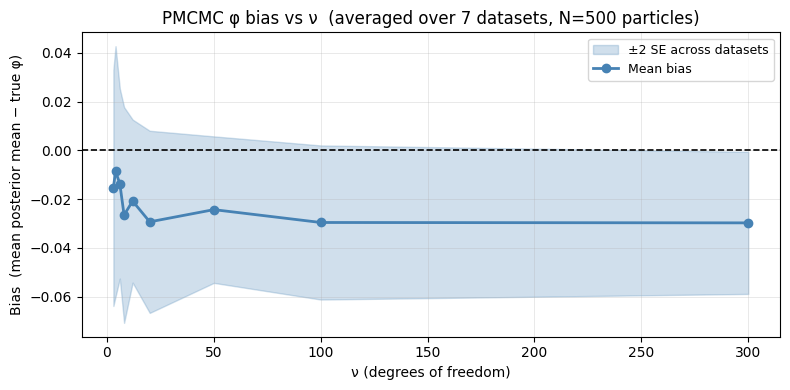

,Mean bias,Std bias,SE
ν,,,
3,-0.015400,0.064000,0.024200
4,-0.008600,0.067900,0.025700
6,-0.013600,0.051500,0.019500
8,-0.026500,0.058500,0.022100
12,-0.020800,0.044200,0.016700
20,-0.029300,0.049400,0.018700
50,-0.024300,0.039700,0.015000
100,-0.029600,0.041800,0.015800
300,-0.029700,0.038500,0.014600


In [ ]:
mean_bias = np.array([np.mean(mc_bias[nu])   for nu in NU_VALUES])
std_bias  = np.array([np.std(mc_bias[nu])    for nu in NU_VALUES])
se_bias   = std_bias / np.sqrt(N_MC)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(NU_VALUES, mean_bias - 2*se_bias, mean_bias + 2*se_bias,
                alpha=0.25, color='steelblue', label='±2 SE across datasets')
ax.plot(NU_VALUES, mean_bias, 'o-', color='steelblue', lw=2, ms=6, label='Mean bias')
ax.axhline(0, color='k', ls='--', lw=1.2)
ax.set_xlabel('ν (degrees of freedom)')
ax.set_ylabel('Bias  (mean posterior mean − true φ)')
ax.set_title(f'PMCMC φ bias vs ν  (averaged over {N_MC} datasets, N={N_PART_MC} particles)')
ax.legend(fontsize=9); ax.grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig('figs/diag_phi_bias_curve_mc.png', dpi=150, bbox_inches='tight')
plt.show()

# table
df_mc = pd.DataFrame({
    'ν':         NU_VALUES,
    'Mean bias': np.round(mean_bias, 4),
    'Std bias':  np.round(std_bias,  4),
    'SE':        np.round(se_bias,   4),
}).set_index('ν')
display(
    df_mc.style
    .set_caption(f'MC-averaged PMCMC φ bias vs ν  ({N_MC} datasets per ν)')
    .set_properties(**{'text-align': 'center'})
)

Bias doesn't change with nu

We are concerned that the prior may be flat in log space and therefore Jeffrey's prior / informative / peaked around 0 in the parameter space:

  [PMCMC] sigma  acceptance rate: 0.680  (TUNE proposal_sd)


/var/folders/9z/nmz60b152q10l03t3_0by17c0000gp/T/ipykernel_64560/481712777.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8); axes[0].grid(True, lw=0.3, alpha=0.5)
/var/folders/9z/nmz60b152q10l03t3_0by17c0000gp/T/ipykernel_64560/481712777.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8); axes[1].grid(True, lw=0.3, alpha=0.5)


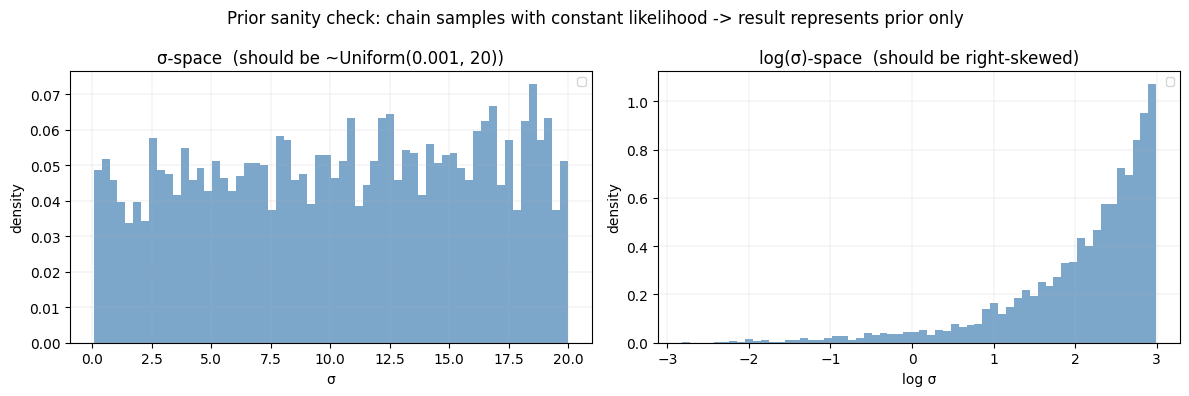

In [ ]:
# patch the filter to return a constant log-likelihood
# With log-lik constant, the MH ratio reduces to prior + Jacobian terms only,
# so the chain samples purely from the effective prior baked into the code
_orig_filter = ss._bootstrap_filter_loglik
ss._bootstrap_filter_loglik = lambda y, p, rng, **kw: 0.0

try:
    res_prior = ss.pmcmc_inference(
        y_inf, p_inf,
        n_iter=5000,
        free=('sigma',),
        proposal_sd={'sigma': 0.5},   # wider steps to be quick
        n_particles=1,                # irrelevant as we mock the filter
        seed=0,
        reparameterise=True,
    )
finally:
    ss._bootstrap_filter_loglik = _orig_filter  # always restore

samples = res_prior['samples']['sigma']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Prior sanity check: chain samples with constant likelihood -> result represents prior only', fontsize=12)

axes[0].hist(samples, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('σ'); axes[0].set_ylabel('density')
axes[0].set_title('σ-space  (should be ~Uniform(0.001, 20))')
axes[0].legend(fontsize=8); axes[0].grid(True, lw=0.3, alpha=0.5)

axes[1].hist(np.log(samples), bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('log σ'); axes[1].set_ylabel('density')
axes[1].set_title('log(σ)-space  (should be right-skewed)')
axes[1].legend(fontsize=8); axes[1].grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()


We can also check this by increasing t drastically since this should kill off any impact of the prior. And indeed it seems to converge to the truth as T -> \inf as below:

  [PMCMC] sigma  acceptance rate: 0.741  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.564  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.297  (ok)


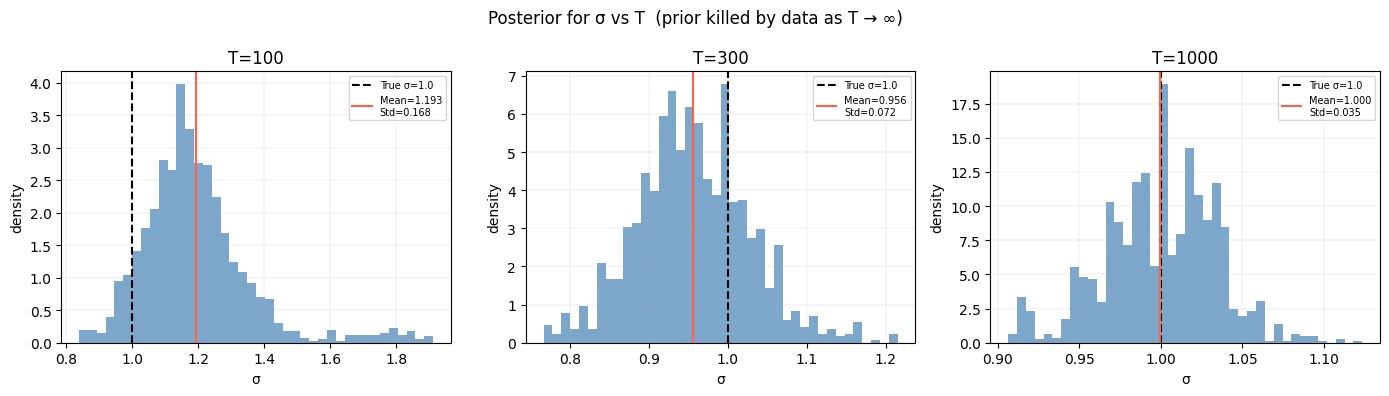

In [ ]:
T_VALUES    = [100, 300, 1000]
N_ITER_T    = 3000
N_PART_T    = 500
BURN_T      = N_ITER_T // 2

fig, axes = plt.subplots(1, len(T_VALUES), figsize=(14, 4), sharey=False)
fig.suptitle('Posterior for σ vs T  (prior killed by data as T → ∞)', fontsize=12)

for ax, T in zip(axes, T_VALUES):
    p_T   = replace(p_inf, T=T)
    rng_T = np.random.default_rng(SEED)
    _, y_T = ss.simulate(p_T, rng_T)

    res_T = ss.pmcmc_inference(
        y_T, p_T,
        n_iter=N_ITER_T,
        free=('sigma',),
        proposal_sd={'sigma': 0.03},
        n_particles=N_PART_T,
        seed=SEED,
        reparameterise=True,
    )
    post = res_T['samples']['sigma'][BURN_T:]

    ax.hist(post, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(TRUE['sigma'], color='k', ls='--', lw=1.5, label=f"True σ={TRUE['sigma']}")
    ax.axvline(post.mean(),   color='tomato', ls='-', lw=1.5,
               label=f'Mean={post.mean():.3f}\nStd={post.std():.3f}')
    ax.set_title(f'T={T}')
    ax.set_xlabel('σ'); ax.set_ylabel('density')
    ax.legend(fontsize=7); ax.grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()


## HPC run chain mixing
Trace plots for a representative sample spanning the ν ESS distribution
(5th, 25th, 50th, 75th, 95th percentile by ν ESS across the 100 HPC reps)

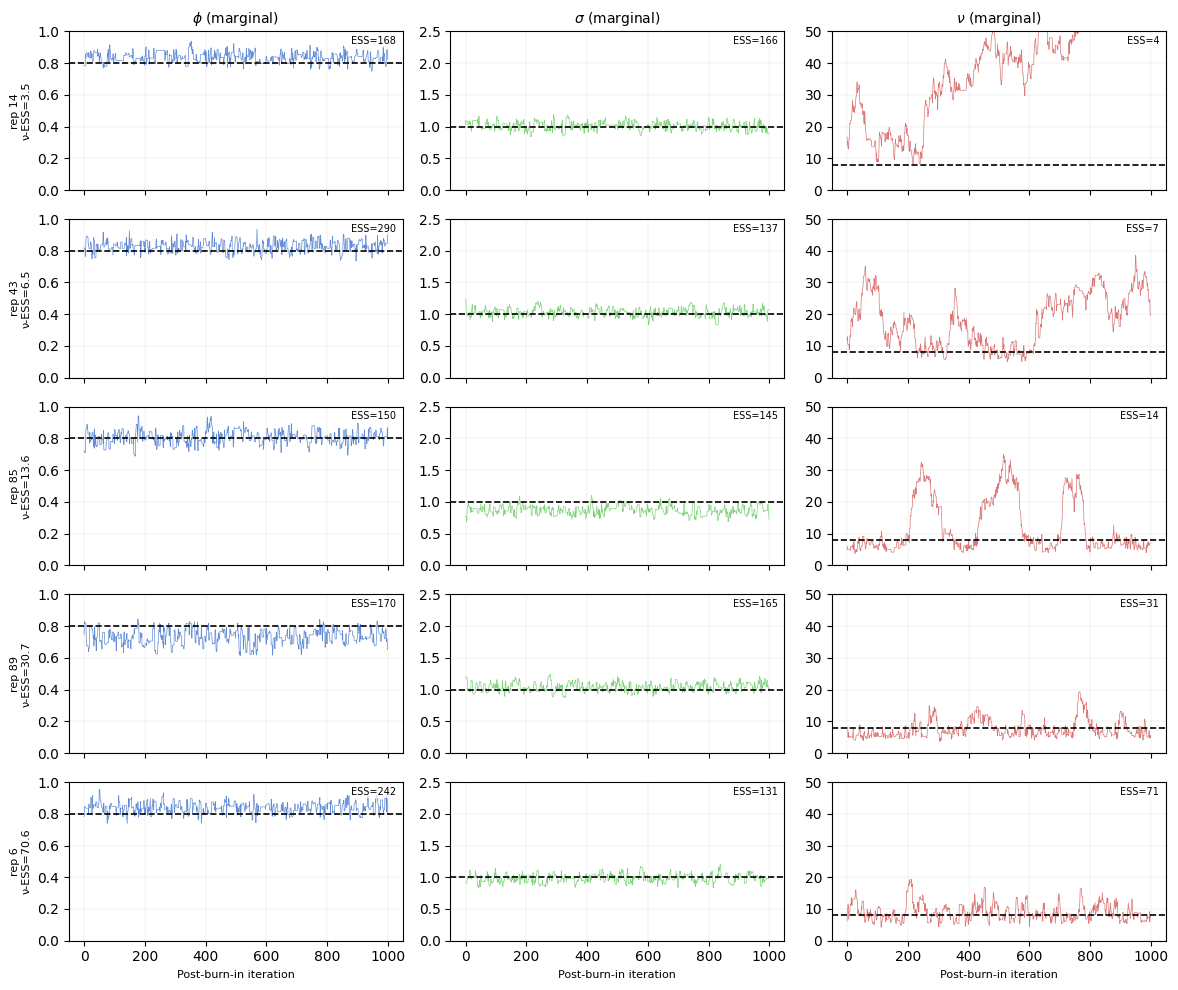

Saved figs/hpc_traces.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = 'figs/hpc_runs'
TRUE = {'phi': 0.8, 'sigma': 1.0, 'nu': 8.0}

# ESS 
def _acf(x, max_lag=500):
    x = x - x.mean()
    var = np.dot(x, x)
    if var == 0:
        return np.zeros(max_lag)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / var for k in range(1, max_lag + 1)])

def ess(samples):
    n = len(samples)
    a = _acf(samples, min(n - 1, 500))
    ps = []
    for k in range(0, len(a) - 1, 2):
        s = a[k] + a[k + 1]
        if s <= 0:
            break
        ps.append(s)
    return n / (1 + 2 * sum(ps))

# pick 5 
nu_ess_ranked = []
for i in range(100):
    d = np.load(f'{RESULTS_DIR}/pmcmc_rep_{i}.npz')
    nu_ess_ranked.append((ess(d['nu_samples']), i))
nu_ess_ranked.sort()

# 5th, 25th, 50th, 75th, 95th percentile reps by nu ESS
rep_indices = [nu_ess_ranked[p][1] for p in [4, 24, 49, 74, 94]]
rep_nu_ess  = [nu_ess_ranked[p][0] for p in [4, 24, 49, 74, 94]]

# load samples 
data = {}
for idx in rep_indices:
    data[idx] = np.load(f'{RESULTS_DIR}/pmcmc_rep_{idx}.npz')

params   = [('phi_samples',   r'$\phi$',   '#4878CF', (0.0, 1.0)),
            ('sigma_samples', r'$\sigma$',  '#6ACC65', (0.0, 2.5)),
            ('nu_samples',    r'$\nu$',     '#D65F5F', (0.0, 50.0))]
n_reps   = len(rep_indices)
n_params = len(params)

fig, axes = plt.subplots(n_reps, n_params, figsize=(12, 10), sharey=False)

for row, (rep_idx, nu_e) in enumerate(zip(rep_indices, rep_nu_ess)):
    d = data[rep_idx]
    n_samp = len(d['phi_samples'])
    iters  = np.arange(n_samp)

    for col, (key, label, colour, ylim) in enumerate(params):
        ax   = axes[row, col]
        samp = d[key]
        pname = key.split('_')[0]   # 'phi', 'sigma', 'nu'
        true_val = TRUE[pname]
        e = ess(samp)

        ax.plot(iters, samp, lw=0.5, color=colour, alpha=0.85)
        ax.axhline(true_val, color='k', ls='--', lw=1.2)
        ax.set_ylim(*ylim)
        ax.grid(True, lw=0.3, alpha=0.4)

        # column header on top row
        if row == 0:
            ax.set_title(f'{label} (marginal)', fontsize=10)

        # row label: rep index + nu ESS
        if col == 0:
            ax.set_ylabel(f'rep {rep_idx}\nν-ESS={nu_e:.1f}', fontsize=8)

        # x-label only on bottom row
        if row == n_reps - 1:
            ax.set_xlabel('Post-burn-in iteration', fontsize=8)
        else:
            ax.set_xticklabels([])

        # ESS annotation in corner
        ax.text(0.98, 0.97, f'ESS={e:.0f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=7,
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))


plt.tight_layout()
plt.savefig('figs/hpc_traces.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/hpc_traces.png')